# Rossmann Store Sales Forecasting

<style>
@page { size: A4; margin: 16mm; }
.jp-InputArea, .jp-InputArea-editor { overflow: visible !important; }
.jp-InputArea pre {
    white-space: pre-wrap !important;
    overflow-wrap: anywhere;
    font-size: 11px;
    line-height: 1.25;
}
</style>

## Executive Summary

This project forecasts combined daily sales for 223 Rossmann stores selected using 1 January-3 July 2015 sales. They contributed 30.5% of sales across the dataset's 1,115 stores in that period. Only the training dataset is used; forecasting requires complete portfolio coverage, yielding 730 training days.

A weekday baseline and multiple linear regression were evaluated on 4-31 July 2015. Regression reduced daily MAE from 264,217 to 109,611 sales units (58.5%). It forecast 57.33 million against 56.54 million actual sales, overestimating the four-week total by 1.40%.

Regression provides the stronger planning reference in this window, assuming advance opening and promotion schedules. Managers should inspect daily errors when setting revenue targets. Further chronological evaluation, including holidays, and an agreed acceptable error are needed before operational use.

## 1. Business Problem and Data

Rossmann operates more than 3,000 drug stores across seven European countries. Sales forecasting supports revenue planning when opening schedules, promotions and calendar effects change. This analysis focuses on the highest-sales 20% of stores. The selected 223 stores account for **30.5% of sales across the dataset's 1,115 stores during 1 January-3 July 2015**, calculated in Section 3.3. This gives managers a focused planning reference for a substantial share of the observed revenue.

The Rossmann training dataset contains 1,017,209 store-day observations from 1,115 stores between 1 January 2013 and 31 July 2015. The notebook reads the original CSV or its losslessly compressed gzip version from `data/raw/` and reproduces the cleaning before analysis. The public repository does not redistribute the dataset; setup instructions link to the original Kaggle source.

Each row describes **one store on one date**, including recorded closed days. The nine fields have the following roles:

| Field(s) | Meaning and analytical role |
|---|---|
| `Store`, `Date` | Store identifier and calendar date; together identify a store-day. |
| `Sales` | Daily store sales; numeric target, aggregated for the selected portfolio. |
| `Customers` | Daily customer count; historical EDA only, as future counts are unavailable. |
| `DayOfWeek` | Weekday category: 1 = Monday through 7 = Sunday. |
| `Open`, `Promo` | Binary flags: 1 = open / promotion, 0 = closed / no promotion. |
| `StateHoliday` | Holiday category: `0` = none; `a`, `b`, `c` mark holiday types. |
| `SchoolHoliday` | Binary flag: 1 = school holiday, 0 = no school holiday. |

Sales retain the dataset's original units; the source does not specify a currency. Opening and promotion flags are assumed to reflect advance plans for the historical forecasting exercise (Section 5.1).

> **How accurately can Rossmann forecast the combined daily sales of its top 20% highest-sales stores over the next 28 days to set short-term revenue targets?**

Supporting question: **Which observable factors are associated with daily sales among the selected stores?** The result will be a portfolio-level target for this priority group rather than a company-wide forecast.

## 2. Objectives, Scope and Limitations

The analysis calculates sales statistics for each selected store and the full group, examines trends and factor associations with the specified plots, and compares a baseline with a simple model to provide a 28-day sales forecast that informs revenue targets.

The descriptive unit is one store-day. Stores are ranked by total sales from 1 January to 3 July 2015, and the selected group's combined daily `Sales` are evaluated from 4 to 31 July 2015 while preserving time order.

The data cannot support product-level replenishment or exact staffing decisions because product demand, labour hours and costs are unavailable. Future customer counts are also unavailable, so `Customers` is limited to explanatory analysis. Observational relationships are interpreted as associations, and missing calendar rows are not treated as zero sales or closed days.

## 3. Data Cleaning and Preparation

This run starts with the original training data stored in the repository, audits duplicates and missingness, standardises formats and checks calendar coverage before preparing the analytical sample. All code remains visible. Plausible unusual observations and missing calendar rows are not replaced with invented values.

### 3.1 Load and audit the repository data

Download the training data from the Kaggle source linked in the README, save it in `data/raw/` as `Rossmann_train.csv` or `Rossmann_train.csv.gz`, and run all cells using Python with pandas, matplotlib and scikit-learn. Cleaning is reproduced in memory and the input file is not overwritten.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

repository = Path(".")
compressed_path = repository / "data/raw/Rossmann_train.csv.gz"
csv_path = repository / "data/raw/Rossmann_train.csv"
INPUT_PATH = compressed_path if compressed_path.is_file() else csv_path
if not INPUT_PATH.is_file():
    raise FileNotFoundError(
        "Download the Kaggle training data to data/raw/Rossmann_train.csv or .csv.gz"
    )

train_input = pd.read_csv(INPUT_PATH, low_memory=False)
initial_audit = pd.Series({
    "Input file": str(INPUT_PATH),
    "Rows": len(train_input),
    "Columns": train_input.shape[1],
    "Missing cells": int(train_input.isna().sum().sum()),
    "Exact duplicates": int(train_input.duplicated().sum()),
    "Duplicate Store-Date keys": int(train_input.duplicated(["Store", "Date"]).sum()),
})
initial_audit

Input file                   data/raw/Rossmann_train.csv.gz
Rows                                                1017209
Columns                                                   9
Missing cells                                             0
Exact duplicates                                          0
Duplicate Store-Date keys                                 0
dtype: object

### 3.2 Clean and check data quality

- Standardise date, integer and category formats for consistent analysis.
- Remove exact duplicates and stop for manual review if conflicting `Store + Date` keys exist.
- Retain plausible open zero-sales records, record calendar coverage and do not create unsupported zero-sales rows.

In [2]:
train_clean = train_input.drop_duplicates().copy()
train_clean.columns = train_clean.columns.str.strip()
train_clean["Date"] = pd.to_datetime(train_clean["Date"], errors="raise")
train_clean["StateHoliday"] = train_clean["StateHoliday"].astype("string").str.strip()

integer_columns = [
    "Store", "DayOfWeek", "Sales", "Customers",
    "Open", "Promo", "SchoolHoliday",
]
train_clean[integer_columns] = train_clean[integer_columns].astype(int)
train_clean = train_clean.sort_values(["Store", "Date"]).reset_index(drop=True)

assert train_clean.duplicated(["Store", "Date"]).sum() == 0
assert train_clean[["Sales", "Customers"]].ge(0).all().all()
valid_values = {
    "DayOfWeek": range(1, 8), "Open": [0, 1], "Promo": [0, 1],
    "SchoolHoliday": [0, 1], "StateHoliday": ["0", "a", "b", "c"],
}
for column, allowed in valid_values.items():
    assert train_clean[column].isin(allowed).all()
assert train_clean["DayOfWeek"].eq(train_clean["Date"].dt.dayofweek + 1).all()

expected_days = len(pd.date_range(train_clean["Date"].min(), train_clean["Date"].max()))
observed_days = train_clean.groupby("Store")["Date"].nunique()
missing_days = expected_days - observed_days

train_quality_checks = pd.Series({
    "Closed rows with positive sales": len(train_clean.query("Open == 0 and Sales > 0")),
    "Open rows with zero sales": len(train_clean.query("Open == 1 and Sales == 0")),
    "Open zero-sales rows with customers": len(train_clean.query(
        "Open == 1 and Sales == 0 and Customers > 0"
    )),
    "Stores with complete coverage": int(missing_days.eq(0).sum()),
    "Stores missing one calendar day": int(missing_days.eq(1).sum()),
    "Stores missing 184 calendar days": int(missing_days.eq(184).sum()),
})
train_quality_checks

Closed rows with positive sales          0
Open rows with zero sales               54
Open zero-sales rows with customers      2
Stores with complete coverage          934
Stores missing one calendar day          1
Stores missing 184 calendar days       180
dtype: int64

The unusual zero-sales observations are retained because the available fields do not establish that they are incorrect. Missing calendar rows are also left unfilled because a missing row provides no evidence that sales were zero. A common complete period is therefore used to rank stores fairly.

### 3.3 Select the top 20% and validate the result

In [3]:
ranking_start = pd.Timestamp("2015-01-01")
ranking_end = pd.Timestamp("2015-07-03")
evaluation_start = pd.Timestamp("2015-07-04")
evaluation_end = pd.Timestamp("2015-07-31")

ranking_data = train_clean[train_clean["Date"].between(ranking_start, ranking_end)]
ranking_coverage = ranking_data.groupby("Store")["Date"].nunique()
assert ranking_coverage.nunique() == 1

store_ranking = ranking_data.groupby("Store")["Sales"].sum().sort_values(ascending=False)
top_store_count = math.ceil(0.20 * len(store_ranking))
top_store_ids = store_ranking.head(top_store_count).index
top_stores = train_clean[train_clean["Store"].isin(top_store_ids)].copy()
ranking_sales_share = 100 * store_ranking.loc[top_store_ids].sum() / store_ranking.sum()

store_date_duplicates = int(train_clean.duplicated(["Store", "Date"]).sum())
sales_preserved = train_clean["Sales"].sum() == train_input["Sales"].sum()
customers_preserved = train_clean["Customers"].sum() == train_input["Customers"].sum()

validation = pd.Series({
    "Ranking period": f"{ranking_start.date()} to {ranking_end.date()}",
    "Days per store in ranking": int(ranking_coverage.iloc[0]),
    "Stores ranked": len(store_ranking),
    "Top stores selected": len(top_store_ids),
    "Selected share of ranking-period sales (%)": round(ranking_sales_share, 1),
    "Evaluation period": f"{evaluation_start.date()} to {evaluation_end.date()}",
    "Evaluation days": len(pd.date_range(evaluation_start, evaluation_end)),
    "Raw train rows": len(train_input),
    "Clean train rows": len(train_clean),
    "Rows removed in this run": len(train_input) - len(train_clean),
    "Duplicate Store-Date rows": store_date_duplicates,
    "Missing train cells": int(train_clean.isna().sum().sum()),
    "Sales total preserved": sales_preserved,
    "Customers total preserved": customers_preserved,
})

assert validation["Sales total preserved"]
assert validation["Customers total preserved"]
validation

Ranking period                                2015-01-01 to 2015-07-03
Days per store in ranking                                          184
Stores ranked                                                     1115
Top stores selected                                                223
Selected share of ranking-period sales (%)                      30.500
Evaluation period                             2015-07-04 to 2015-07-31
Evaluation days                                                     28
Raw train rows                                                 1017209
Clean train rows                                               1017209
Rows removed in this run                                             0
Duplicate Store-Date rows                                            0
Missing train cells                                                  0
Sales total preserved                                             True
Customers total preserved                                         True
dtype:

### 3.4 Cleaning outcome

The raw input has no exact duplicates, conflicting Store-Date keys or missing cells. Dates and categories are standardised to suitable Python types; no imputation is needed. The cleaned data preserve all original rows, sales and customer totals, including plausible unusual observations and existing calendar gaps. These checks compare the raw input with the in-memory cleaned result. Neither repository CSV is overwritten. Selection yields 223 stores before the 28-day evaluation period.

## 4. Descriptive Statistics and Exploratory Data Analysis

EDA uses only observations dated before the 28-day evaluation period. This preserves the final four weeks as unseen data for model evaluation. The EDA focuses on evidence that informs the later forecasting model.

### 4.1 Development sample and required sales statistics

In [4]:
development_data = top_stores[top_stores["Date"] < evaluation_start].copy()
evaluation_schedule = top_stores.loc[
    top_stores["Date"].between(evaluation_start, evaluation_end), ["Store", "Date"]
]
assert development_data["Date"].max() == ranking_end
assert evaluation_schedule.groupby("Store")["Date"].nunique().eq(28).all()

store_sales_statistics = development_data.groupby("Store")["Sales"].agg(
    Observations="count", Mean="mean", Standard_deviation="std",
    Minimum="min", Maximum="max"
)
overall_sales_statistics = development_data["Sales"].agg(
    ["count", "mean", "std", "min", "max"]
).rename({"count": "Observations", "mean": "Mean", "std": "Standard deviation",
          "min": "Minimum", "max": "Maximum"}).to_frame("All selected stores")
store_comparison = pd.concat([
    store_sales_statistics.nlargest(3, "Mean").assign(Group="Highest mean"),
    store_sales_statistics.nsmallest(3, "Mean").assign(Group="Lowest mean")
])[["Group", "Observations", "Mean", "Standard_deviation", "Minimum", "Maximum"]]
display(overall_sales_statistics, store_comparison)

,All selected stores
Observations,"198,854.000"
Mean,"8,762.890"
Standard deviation,"5,117.925"
Minimum,0.000
Maximum,"41,551.000"


,Group,Observations,Mean,Standard_deviation,Minimum,Maximum
Store,,,,,,
262,Highest mean,914,"20,688.670","4,668.079",13210,38722
817,Highest mean,914,"18,125.352","9,216.669",0,38025
562,Highest mean,914,"17,990.011","2,939.378",8498,28680
349,Lowest mean,914,"6,023.485","3,798.734",0,24672
684,Lowest mean,730,"6,279.933","3,608.530",0,16043
791,Lowest mean,914,"6,318.845","3,514.821",0,17108


The development sample contains 198,854 observations from 223 stores before 4 July 2015. Mean daily store sales were 8,762.9 (standard deviation 5,117.9), ranging from 0 to 41,551. Store means ranged from 6,023.5 to 20,688.7. These describe available records: 196 stores have 914 days each, while 27 have 730. Unequal observation periods limit direct performance comparisons between stores; the forecasting target is their combined daily sales.

### 4.2 Required plots, factor summaries and correlations

In [5]:
open_development = development_data[development_data["Open"].eq(1)].copy()
factor_tables = []
for factor, data in [("Open", development_data)] + [
    (name, open_development)
    for name in ["DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday"]
]:
    table = data.groupby(factor)["Sales"].agg(Observations="count", Mean_sales="mean")
    table.index = table.index.astype(str)
    table["Factor"] = factor
    factor_tables.append(table.reset_index(names="Category"))
factor_summary = pd.concat(factor_tables, ignore_index=True)[
    ["Factor", "Category", "Observations", "Mean_sales"]
]

correlation_columns = ["Sales", "Customers", "Open", "Promo", "SchoolHoliday"]
sales_correlations = development_data[correlation_columns].corr()["Sales"].drop("Sales")
customer_sales_correlation = open_development[["Customers", "Sales"]].corr().iloc[0, 1]
display(factor_summary, sales_correlations.sort_values(ascending=False).to_frame(
    "Pearson r with Sales (all recorded days)"))

,Factor,Category,Observations,Mean_sales
0,Open,0,32188,0.000
1,Open,1,166666,"10,455.256"
2,DayOfWeek,1,26942,"12,190.342"
3,DayOfWeek,2,28177,"10,622.439"
4,DayOfWeek,3,27772,"10,075.054"
5,DayOfWeek,4,26414,"10,133.785"
6,DayOfWeek,5,27139,"10,531.017"
7,DayOfWeek,6,28168,"9,189.041"
8,DayOfWeek,7,2054,"11,041.193"
9,Promo,0,92674,"9,079.645"


,Pearson r with Sales (all recorded days)
Customers,0.859
Open,0.752
Promo,0.474
SchoolHoliday,0.080


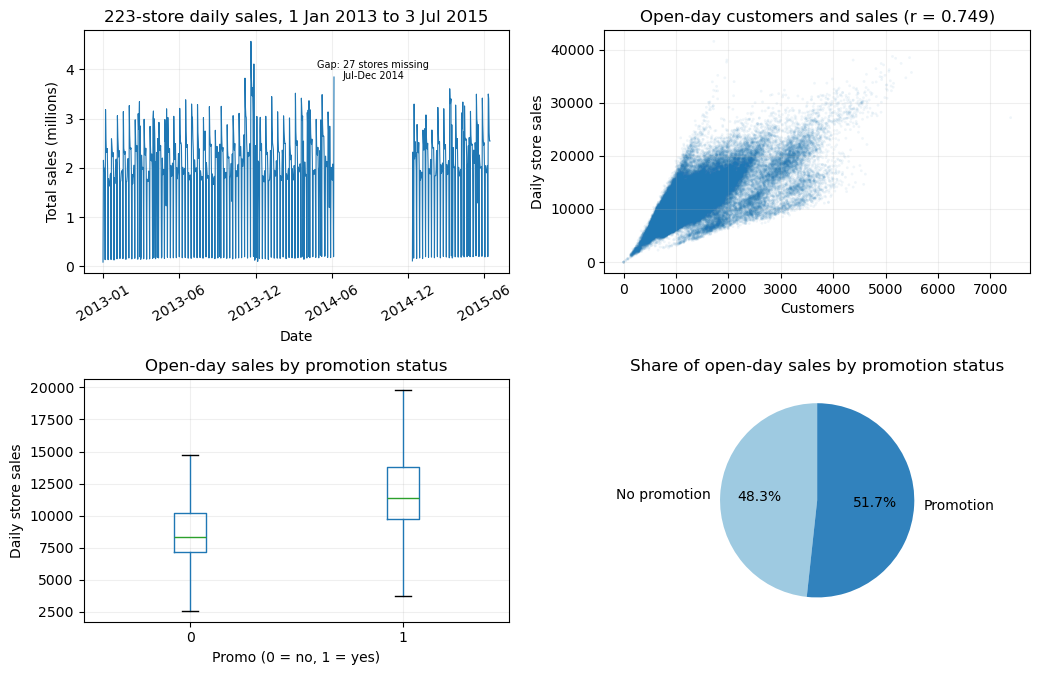

In [6]:
daily_portfolio = development_data.groupby("Date").agg(
    TotalSales=("Sales", "sum"), ObservedStores=("Store", "nunique")
).reindex(pd.date_range(development_data["Date"].min(), ranking_end))
plot_sales = daily_portfolio["TotalSales"].copy()
# Keep calendar gaps visible; never replace missing sales with zero.
plot_sales.loc[daily_portfolio["ObservedStores"].ne(len(top_store_ids))] = float("nan")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0))
axes[0, 0].plot(plot_sales.index, plot_sales / 1_000_000,
                color="#1f77b4", linewidth=0.8)
axes[0, 0].set(title="223-store daily sales, 1 Jan 2013 to 3 Jul 2015",
               xlabel="Date", ylabel="Total sales (millions)")
axes[0, 0].text(pd.Timestamp("2014-10-01"), 3.8,
                "Gap: 27 stores missing\nJul-Dec 2014", ha="center", fontsize=7)
date_ticks = daily_portfolio.index[::180]
axes[0, 0].set_xticks(date_ticks, [date.strftime("%Y-%m") for date in date_ticks], rotation=30)

axes[0, 1].scatter(open_development["Customers"], open_development["Sales"],
                   s=4, alpha=0.07, color="#1f77b4", edgecolors="none")
axes[0, 1].set(title=f"Open-day customers and sales (r = {customer_sales_correlation:.3f})",
               xlabel="Customers", ylabel="Daily store sales")

open_development.boxplot(column="Sales", by="Promo", ax=axes[1, 0],
                         grid=False, showfliers=False)
axes[1, 0].set(title="Open-day sales by promotion status",
               xlabel="Promo (0 = no, 1 = yes)", ylabel="Daily store sales")

promotion_sales = open_development.groupby("Promo")["Sales"].sum().reindex([0, 1])
axes[1, 1].pie(promotion_sales, labels=["No promotion", "Promotion"],
               autopct="%1.1f%%", startangle=90, colors=["#9ecae1", "#3182bd"])
axes[1, 1].set_title("Share of open-day sales by promotion status")
for ax in axes.flat[:3]:
    ax.grid(alpha=0.2)
fig.suptitle("")
plt.tight_layout()
plt.show()

The time-series gap marks **184 dates with only 196 of 223 stores recorded** in July-December 2014; it provides no evidence of a sales fall. The curve uses the 730 complete dates, with closed-store records retained. The weekly pattern supports a weekday baseline: complete-day training means range from approximately 0.17 million on Sundays to 2.55 million on Mondays (Section 5.2). The gap limits conclusions about changes across the missing period.

Among open-store records, mean sales were 12,178.2 during promotion and 9,079.6 without promotion, an observed difference of about 34%. The pie chart's 51.7% promotional sales share also depends on the number of promotional store-days and cannot measure incremental sales caused by promotion. Public-holiday groups contain few open-store records. The boxplot hides outlier markers without deleting data. All comparisons are observational associations.

The correlation table includes all recorded days, including closures; the scatter uses open days only. Their Customers-Sales correlations are 0.859 and 0.749 respectively. Closed days can strengthen the pooled association through simultaneous zeros. Weekday is a cyclic category, so its differences are described by grouped means and later category indicators, without treating codes 1-7 as a continuous scale.

### 4.3 Forecasting decisions and EDA conclusion

| Variable | Decision for the later model |
|---|---|
| `DayOfWeek` | Use as a calendar predictor |
| `Open`, `Promo`, `StateHoliday`, `SchoolHoliday` | Aggregate to daily counts across the selected stores |
| `Customers` | Exclude because future customer counts are unavailable |
| `Date` | Use for ordering and the chronological split |
| `Store` | Use for top-store selection, then aggregate by date |

The Customers-Sales association helps explain historical sales, but future customer counts are unavailable at the forecast origin. The model therefore uses known calendar and assumed planned-event information. The final 28 days are excluded from EDA and model fitting and used only for the forecast evaluation in Section 5.

## 5. Forecast Modelling

### 5.1 Prepare daily inputs and the time split

Each modelling row represents all 223 selected stores on one date. We retain dates with a record for every selected store, including closed-store records. Dates with incomplete coverage are excluded from modelling; their observed sales remain in the cleaned data. This prevents a smaller recorded portfolio from being treated as the full sales target.

Inputs are weekday (1 = Monday, 7 = Sunday) and daily counts of stores marked open, on promotion, on a public holiday or on a school holiday. For this historical forecast exercise, opening and promotion records are assumed to represent plans available on 3 July 2015; holiday calendars are assumed known. Unexpected changes to those plans would affect real forecasts. `Customers` is excluded. Evaluation sales are reserved for later scoring.

In [7]:
# Aggregate schedule fields without evaluation sales or customer counts.
schedule = top_stores[[
    "Date", "Store", "Open", "Promo", "StateHoliday", "SchoolHoliday"
]].copy()
schedule["StateHolidayFlag"] = schedule["StateHoliday"].ne("0").astype(int)
daily_inputs = schedule.groupby("Date").agg(
    ObservedStores=("Store", "nunique"), OpenStores=("Open", "sum"),
    PromoStores=("Promo", "sum"), StateHolidayStores=("StateHolidayFlag", "sum"),
    SchoolHolidayStores=("SchoolHoliday", "sum")
).sort_index()
daily_inputs["DayOfWeek"] = daily_inputs.index.dayofweek + 1

# Zero below means no recorded stores; it does not impute sales.
calendar = pd.date_range(top_stores["Date"].min(), evaluation_end, name="Date")
coverage = daily_inputs["ObservedStores"].reindex(calendar, fill_value=0)
complete_dates = coverage[coverage.eq(len(top_store_ids))].index
excluded_dates = coverage[coverage.lt(len(top_store_ids))].index
assert coverage.loc[evaluation_start:evaluation_end].eq(len(top_store_ids)).all()

feature_columns = [
    "DayOfWeek", "OpenStores", "PromoStores", "StateHolidayStores", "SchoolHolidayStores"
]
complete_inputs = daily_inputs.loc[complete_dates, feature_columns]
X_train = complete_inputs.loc[:ranking_end].copy()
X_eval = complete_inputs.loc[evaluation_start:evaluation_end].copy()
# Training targets come exclusively from pre-evaluation observations.
training_sales = development_data.groupby("Date")["Sales"].sum()
y_train = training_sales.loc[X_train.index].rename("TotalSales")

assert X_train.index.is_unique and X_eval.index.is_unique
assert X_train.index.max() < X_eval.index.min()
assert X_eval.index.equals(pd.date_range(evaluation_start, evaluation_end))
assert X_train.index.equals(y_train.index)
assert X_train.notna().all().all() and X_eval.notna().all().all()
assert y_train.notna().all() and y_train.ge(0).all()
assert "Customers" not in feature_columns and "TotalSales" not in feature_columns

modelling_checks = pd.DataFrame({
    "Sample": ["Training inputs + target", "Evaluation inputs", "Excluded dates"],
    "First date": [X_train.index.min().date(), X_eval.index.min().date(),
                   excluded_dates.min().date()],
    "Last date": [X_train.index.max().date(), X_eval.index.max().date(),
                  excluded_dates.max().date()],
    "Days": [len(X_train), len(X_eval), len(excluded_dates)],
    "Recorded stores/day": [int(coverage.loc[X_train.index].min()),
                           int(coverage.loc[X_eval.index].min()),
                           int(coverage.loc[excluded_dates].min())],
}).set_index("Sample")
modelling_checks

,First date,Last date,Days,Recorded stores/day
Sample,,,,
Training inputs + target,2013-01-01,2015-07-03,730,223
Evaluation inputs,2015-07-04,2015-07-31,28,223
Excluded dates,2014-07-01,2014-12-31,184,196


The training sample has **730 complete days**: 1 January 2013 to 30 June 2014 and 1 January to 3 July 2015. All **28 evaluation days** contain 223 stores. The excluded 184 days (July-December 2014) contain only 196 stores, with 27 missing. Store-level EDA summaries describe available records; both the portfolio time-series curve and modelling sample require full coverage. This exclusion reduces recent seasonal information, so performance must be checked on the held-out period.

The two methods below are fixed before scoring the final 28 days. No evaluation sales are used for fitting, feature selection or tuning. Sales are reported in the dataset's original units; the source does not specify a currency.

### 5.2 Weekday-mean baseline

The baseline predicts each date using the mean combined sales of training dates with the same weekday. For example, every evaluation Monday receives the historical Monday mean. It captures the weekly pattern but ignores promotions, unusual openings, holidays and longer-term changes. Each complete training day has equal weight. The seven means below are learned from training data only.

In [8]:
weekday_means = y_train.groupby(X_train["DayOfWeek"]).mean()
assert weekday_means.index.tolist() == list(range(1, 8))
baseline_train = X_train["DayOfWeek"].map(weekday_means)
baseline_eval = X_eval["DayOfWeek"].map(weekday_means)
assert baseline_train.notna().all() and baseline_eval.notna().all()

baseline_summary = pd.DataFrame({
    "Training days": y_train.groupby(X_train["DayOfWeek"]).count(),
    "Mean total sales": weekday_means
})
baseline_summary.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
baseline_summary.index.name = "Weekday"
baseline_summary.round(0)

,Training days,Mean total sales
Weekday,,
Mon,104,"2,550,135.000"
Tue,104,"2,308,895.000"
Wed,104,"2,181,232.000"
Thu,105,"2,057,467.000"
Fri,105,"2,241,344.000"
Sat,104,"2,043,762.000"
Sun,104,"171,666.000"


### 5.3 Multiple linear regression

The model adds four store-count terms and six weekday indicators to an intercept: **predicted total sales = intercept + weekday adjustment + opening term + promotion term + public-holiday term + school-holiday term**. Monday is the reference weekday, so only Tuesday-Sunday receive indicator columns. Ordinary least squares chooses coefficients to minimise the sum of squared training errors. All predictions use the same fitted model, with no updating during the 28-day horizon.

All five planned fields vary in training. Opening count and the Sunday indicator are strongly related (correlation -0.890), but they describe different information: weekday and actual planned opening coverage. Both are retained, with cautious coefficient interpretation. No variables are selected using evaluation outcomes, and no parameter search is used.

In [9]:
from sklearn.linear_model import LinearRegression

X_reg_train = pd.get_dummies(
    X_train, columns=["DayOfWeek"], drop_first=True, dtype=int
)
X_reg_eval = pd.get_dummies(
    X_eval, columns=["DayOfWeek"], drop_first=True, dtype=int
).reindex(columns=X_reg_train.columns, fill_value=0)
assert X_reg_train.nunique().gt(1).all()
assert X_reg_eval.columns.equals(X_reg_train.columns)
feature_correlations = X_reg_train.corr()
print("Training correlation, OpenStores and Sunday:",
      round(feature_correlations.loc["OpenStores", "DayOfWeek_7"], 3))
print("Training PromoStores levels:", sorted(X_train["PromoStores"].unique().tolist()))

linear_model = LinearRegression()
linear_model.fit(X_reg_train, y_train)
linear_train = pd.Series(linear_model.predict(X_reg_train), index=X_train.index)
linear_eval = pd.Series(linear_model.predict(X_reg_eval), index=X_eval.index)
coefficients = pd.Series(linear_model.coef_, index=X_reg_train.columns)
coefficient_table = pd.concat([
    pd.Series({"Intercept": linear_model.intercept_}), coefficients
]).to_frame("Sales units per input unit")
coefficient_table.round(1)

Training correlation, OpenStores and Sunday: -0.89
Training PromoStores levels: [0, 223]


,Sales units per input unit
Intercept,"-1,797,042.500"
OpenStores,"18,222.300"
PromoStores,"3,130.200"
StateHolidayStores,"7,446.700"
SchoolHolidayStores,"1,029.000"
DayOfWeek_2,"-342,345.600"
DayOfWeek_3,"-426,481.100"
DayOfWeek_4,"-433,294.300"
DayOfWeek_5,"-340,940.100"
DayOfWeek_6,"-218,490.200"


### 5.4 Evaluate the fixed 28-day forecasts

Evaluation sales are opened only after both sets of predictions exist. **MAE** is the mean absolute daily error; **RMSE** is the square root of the mean squared daily error and penalises large misses. Lower is better for both. **R-squared** compares squared error with predicting the actual sample mean; it is not percentage accuracy and can be negative. Training scores describe fit, while held-out scores provide the forecast comparison. The separate four-week total error is **100 x (predicted total - actual total) / actual total**: positive means overforecasting. Small total error can hide offsetting daily errors.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_predictions = pd.DataFrame({"Baseline": baseline_train, "Regression": linear_train})
eval_predictions = pd.DataFrame({"Baseline": baseline_eval, "Regression": linear_eval})
assert eval_predictions.index.equals(X_eval.index)
assert eval_predictions.shape == (28, 2) and eval_predictions.notna().all().all()

evaluation_rows = top_stores[top_stores["Date"].between(evaluation_start, evaluation_end)]
y_eval = evaluation_rows.groupby("Date")["Sales"].sum().loc[X_eval.index]
assert y_eval.index.equals(eval_predictions.index) and y_eval.notna().all()
score_rows = []
for sample, actual, predictions in [
    ("Training", y_train, train_predictions), ("28-day evaluation", y_eval, eval_predictions)
]:
    for model in predictions:
        predicted = predictions[model]
        score_rows.append({
            "Sample": sample, "Model": model,
            "MAE": mean_absolute_error(actual, predicted),
            "RMSE": mean_squared_error(actual, predicted) ** 0.5,
            "R-squared": r2_score(actual, predicted)
        })
scores = pd.DataFrame(score_rows).set_index(["Sample", "Model"])
scores.round({"MAE": 0, "RMSE": 0, "R-squared": 3})

MAE        RMSE  R-squared
Sample            Model                                        
Training          Baseline   352,235.000 540,185.000      0.650
                  Regression 175,662.000 260,405.000      0.919
28-day evaluation Baseline   264,217.000 333,843.000      0.838
                  Regression 109,611.000 141,682.000      0.971

In [11]:
actual_total = y_eval.sum()
revenue_comparison = pd.DataFrame({
    "Predicted total": eval_predictions.sum(),
    "Total error": eval_predictions.sum() - actual_total,
    "Total error (%)": 100 * (eval_predictions.sum() - actual_total) / actual_total
})
print(f"Actual 28-day sales: {actual_total:,.0f}")
display(revenue_comparison.round({"Predicted total": 0, "Total error": 0,
                                  "Total error (%)": 2}))
# Check regression outputs without clipping values or changing either model.
diagnostic_rows = []
for sample, predictions, inputs in [
    ("Training fit", linear_train, X_train), ("Evaluation", linear_eval, X_eval)
]:
    negative = predictions.lt(0)
    holiday = inputs["StateHolidayStores"].gt(0)
    diagnostic_rows.append([sample, len(predictions), int(negative.sum()),
                            int(holiday.sum()), int((negative & holiday).sum())])
display(pd.DataFrame(diagnostic_rows, columns=[
    "Sample", "Days", "Negative", "Holiday days", "Negative on holidays"
]).set_index("Sample"))

forecast_results = eval_predictions.copy()
forecast_results["Actual"] = y_eval
daily_errors = eval_predictions.sub(y_eval, axis=0)
worst_date = daily_errors["Regression"].abs().idxmax()
print(f"Largest regression daily miss: {worst_date.date()}, "
      f"actual {y_eval.loc[worst_date]:,.0f}, "
      f"predicted {linear_eval.loc[worst_date]:,.0f}")

Actual 28-day sales: 56,542,356


,Predicted total,Total error,Total error (%)
Baseline,"54,218,001.000","-2,324,355.000",-4.110
Regression,"57,332,637.000","790,281.000",1.400


,Days,Negative,Holiday days,Negative on holidays
Sample,,,,
Training fit,730,9,31,9
Evaluation,28,0,0,0


Largest regression daily miss: 2015-07-17, actual 2,342,730, predicted 2,729,186


### 5.5 Forecast pattern and interpretation

The chart displays all 28 portfolio-level forecasts alongside the actual sales from the same selected stores. It makes daily misses visible even when they cancel in the four-week total.

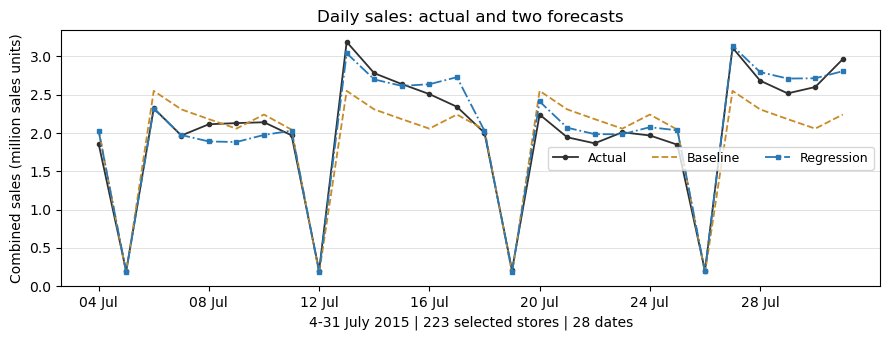

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, color, style, marker in [
    ("Actual", "#303030", "-", "o"),
    ("Baseline", "#c88b26", "--", None),
    ("Regression", "#2878b5", "-.", "s")
]:
    ax.plot(forecast_results.index, forecast_results[name] / 1_000_000,
            label=name, color=color, linestyle=style, marker=marker,
            markersize=3, linewidth=1.3)
ax.set(title="Daily sales: actual and two forecasts",
       xlabel="4-31 July 2015 | 223 selected stores | 28 dates",
       ylabel="Combined sales (million sales units)", ylim=(0, None))
ticks = forecast_results.index[::4]
ax.set_xticks(ticks, [d.strftime("%d Jul") for d in ticks])
ax.grid(axis="y", color="#dddddd", linewidth=0.6)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

**Weekday error diagnosis.** The following table uses the existing, fixed regression predictions. MAE measures the size of daily misses; mean error (predicted minus actual) indicates their direction. Each weekday has only four observations. This descriptive check does not refit or tune the model.

In [13]:
weekday_errors = pd.DataFrame({
    "Weekday": X_eval["DayOfWeek"],
    "Absolute_error": daily_errors["Regression"].abs(),
    "Error": daily_errors["Regression"]
}).groupby("Weekday").agg(
    Days=("Error", "count"), MAE=("Absolute_error", "mean"),
    Mean_error=("Error", "mean")
)
weekday_errors.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_errors.round(0)

,Days,MAE,Mean_error
Mon,4,"87,483.000","9,610.000"
Tue,4,"81,180.000","40,319.000"
Wed,4,"140,432.000","16,227.000"
Thu,4,"128,886.000","-7,646.000"
Fri,4,"204,341.000","42,910.000"
Sat,4,"110,552.000","110,552.000"
Sun,4,"14,401.000","-14,401.000"


**Forecast performance.** Regression reduced held-out MAE by 58.5% and RMSE by 57.6% relative to the weekday baseline. R-squared was 0.971, not 97.1% forecast accuracy. Lower evaluation error than training error reflects a different, short July sample. The largest regression miss was 17 July: 2,729,186 predicted against 2,342,730 actual, an overforecast of 386,456.

**Non-negative sales check.** Regression produced 9 negative fitted values across 730 training days, all on public holidays. Unconstrained linear regression permits negative outputs, which are impossible for sales and reveal poor fit on these dates. These are training fits; the 28 evaluation forecasts are non-negative, but contain no public holidays. July scores therefore cannot establish holiday reliability. No dates are deleted and no outputs are clipped; the models and reported scores remain unchanged.

Friday MAE was 204,341, compared with 14,401 on Sundays. Sunday's much smaller sales limit comparisons of relative accuracy using these absolute errors. All four Saturdays were overforecast (mean error and MAE both 110,552). These results identify dates for review, but four observations per weekday cannot establish persistent patterns or causes. No model changes were made after this diagnosis.

**What the coefficients mean.** With other inputs fixed, Tuesday is predicted 342,346 sales units below Monday. Promotion count varies only between 0 and 223: its implied all-store contrast is about 698,000 units; a one-store change lacks empirical support. The positive Sunday term partly offsets fewer open stores and does not imply high Sunday sales. Correlated inputs complicate the positive public-holiday coefficient. The negative intercept describes an unobserved all-zero-input Monday. Coefficients express conditional associations; their raw magnitudes cannot establish variable importance or causal effects.

## 6. Conclusions and Further Steps

**Answer to the business problem.** For the selected 223 stores, regression outperformed the weekday baseline in July 2015, with daily MAE of 109,611 sales units. Its four-week forecast of 57.33 million exceeded actual sales of 56.54 million by 0.79 million (1.40%); the baseline underforecast by 2.32 million (4.11%). Weekday, opening and promotion associations supported the inputs, without establishing causal effects.

**Management use.** Use expected sales as a revenue-planning reference and compare actuals with predictions, especially Friday misses and Saturday overforecasting. Total error can conceal offsetting daily misses. Management targets require business objectives and risk tolerance; no acceptable-error threshold was supplied. Results cannot establish company-wide performance or exact inventory and staffing needs.

**Limits of the evidence.** Nine negative training fits reveal a public-holiday weakness; the single July evaluation window contains no public holidays. Holiday forecasts require separate review and later validation before operational use. Opening and promotion schedules are assumed known in advance. Missing 2014 coverage limits seasonal evidence; the additive model omits explicit annual seasonality, trend and interactions. No prediction interval is estimated.

**Further steps within the existing methods.** Obtain later observations, including holidays, and repeat chronological 28-day comparisons using MAE, RMSE and total error. If errors recur, assess additional calendar indicators in linear regression, testing revisions on a separate later period. Agree acceptable daily and four-week errors with managers before adoption. These steps remain proposed work.

## References

- Kaggle. *Rossmann Store Sales: Data*. https://www.kaggle.com/c/rossmann-store-sales/data
